In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'results\uploads\diabetes.csv')
df_clean = None
df_features = None
DATASET_COLUMNS = list(df_raw.columns)
NUMERIC_COLUMNS = df_raw.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLUMNS = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
DATASET_SHAPE = df_raw.shape
ORIGINAL_NUMERIC_COLUMNS = NUMERIC_COLUMNS.copy()
ORIGINAL_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS.copy()
print(f"Loaded {DATASET_SHAPE[0]} rows x {DATASET_SHAPE[1]} columns")


Loaded 1150 rows x 20 columns


In [ ]:

import json as _json

# Compute correlations for numeric columns
_corr_matrix = df_raw[NUMERIC_COLUMNS].corr() if len(NUMERIC_COLUMNS) > 1 else None
_top_correlations = []
if _corr_matrix is not None:
    for i, col1 in enumerate(NUMERIC_COLUMNS):
        for col2 in NUMERIC_COLUMNS[i+1:]:
            corr_val = abs(_corr_matrix.loc[col1, col2])
            if corr_val > 0.5:
                _top_correlations.append((col1, col2, round(corr_val, 3)))
    _top_correlations.sort(key=lambda x: x[2], reverse=True)
    _top_correlations = _top_correlations[:10]  # Top 10

# Compute skewness for numeric columns
_skewness = {}
for col in NUMERIC_COLUMNS:
    try:
        _skewness[col] = round(float(df_raw[col].skew()), 3)
    except:
        pass
_highly_skewed = [col for col, skew in _skewness.items() if abs(skew) > 1]

# Identify binary columns
_binary_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 2]

# Identify potential target columns (binary or low cardinality categorical)
_potential_targets = [col for col in df_raw.columns if 2 <= df_raw[col].nunique() <= 10]

_profile = {
    'shape': list(df_raw.shape),
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'numeric_columns': NUMERIC_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'missing_values': df_raw.isnull().sum().to_dict(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1).to_dict(),
    'duplicates': int(df_raw.duplicated().sum()),
    'describe': df_raw.describe().round(2).to_dict(),
    'top_correlations': _top_correlations,
    'highly_skewed_columns': _highly_skewed,
    'skewness': _skewness,
    'binary_columns': _binary_columns,
    'potential_targets': _potential_targets,
}
print(_json.dumps(_profile))


{"shape": [1150, 20], "columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "dtypes": {"A": "int64", "B": "int64", "C": "int64", "D": "int64", "E": "int64", "F": "int64", "G": "int64", "H": "int64", "I": "float64", "J": "float64", "K": "float64", "L": "float64", "M": "float64", "N": "float64", "O": "float64", "P": "float64", "Q": "float64", "R": "float64", "S": "int64", "T": "int64"}, "numeric_columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "categorical_columns": [], "missing_values": {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "H": 0, "I": 0, "J": 0, "K": 0, "L": 0, "M": 0, "N": 0, "O": 0, "P": 0, "Q": 0, "R": 0, "S": 0, "T": 0}, "missing_pct": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "F": 0.0, "G": 0.0, "H": 0.0, "I": 0.0, "J": 0.0, "K": 0.0, "L": 0.0, "M": 0.0, "N": 0.0, "O": 0.0, "P": 0.0, "Q": 0.0, "R": 0.0, "S": 0.0, "T": 0.0}, "duplica

In [ ]:

_available = {}
for _name in ['df_raw', 'df_clean', 'df_features']:
    _obj = globals().get(_name)
    if _obj is not None and hasattr(_obj, 'shape'):
        _available[_name] = list(_obj.shape)
print(f"Available DataFrames: {_available}")
print(f"NUMERIC_COLUMNS: {globals().get('NUMERIC_COLUMNS', 'NOT SET')}")
print(f"CATEGORICAL_COLUMNS: {globals().get('CATEGORICAL_COLUMNS', 'NOT SET')}")


Available DataFrames: {'df_raw': [1150, 20]}
NUMERIC_COLUMNS: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']
CATEGORICAL_COLUMNS: []


In [ ]:
df_clean = df_raw.copy()
initial_rows = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
duplicate_rows_removed = initial_rows - df_clean.shape[0]
print(f"Removed {duplicate_rows_removed} duplicate rows.")

Removed 5 duplicate rows.


In [ ]:
print(type(df_raw).__name__)

DataFrame


In [ ]:

_available = {}
for _name in ['df_raw', 'df_clean', 'df_features']:
    _obj = globals().get(_name)
    if _obj is not None and hasattr(_obj, 'shape'):
        _available[_name] = list(_obj.shape)
print(f"Available DataFrames: {_available}")
print(f"NUMERIC_COLUMNS: {globals().get('NUMERIC_COLUMNS', 'NOT SET')}")
print(f"CATEGORICAL_COLUMNS: {globals().get('CATEGORICAL_COLUMNS', 'NOT SET')}")


Available DataFrames: {'df_raw': [1150, 20], 'df_clean': [1145, 20]}
NUMERIC_COLUMNS: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']
CATEGORICAL_COLUMNS: []


In [ ]:
import pandas as pd

# Get basic info and descriptive statistics
print("DataFrame Info:")
df_clean.info()
print("\nDescriptive Statistics:")
print(df_clean.describe())

# Calculate skewness for all numeric columns
skewness = df_clean[NUMERIC_COLUMNS].skew().sort_values(ascending=False)
print("\nSkewness of Numeric Columns:")
print(skewness)

# Calculate correlation matrix
correlation_matrix = df_clean[NUMERIC_COLUMNS].corr()

# Find highly correlated pairs (absolute correlation > 0.5)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

high_corr_pairs_sorted = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print("\nHighly Correlated Pairs (> 0.5 absolute correlation):")
for col1, col2, corr_val in high_corr_pairs_sorted:
    print(f"  {col1} - {col2}: {corr_val:.4f}")

# Identify highly skewed columns (|skewness| > 1)
highly_skewed_columns = skewness[abs(skewness) > 1].index.tolist()

print("\nColumns with |skewness| > 1:")
print(highly_skewed_columns)

# Prepare for output
top_correlations_output = []
for col1, col2, corr_val in high_corr_pairs_sorted:
    top_correlations_output.append(f"{col1} - {col2}: {corr_val:.4f}")

skewed_columns_output = highly_skewed_columns

notable_patterns = []
# Check for target variable relationships specifically
# No explicit relationship is immediately visible from just numbers, but we can infer general patterns.
# For example, if 'A' and 'B' are highly correlated, or 'S' and 'T'.

# Check correlations among the specified target variables
target_vars = ['A', 'B', 'S', 'T']
target_corr_matrix = df_clean[target_vars].corr()

if abs(target_corr_matrix.loc['A', 'B']) > 0.5:
    notable_patterns.append(f"Strong correlation between target variables A and B ({target_corr_matrix.loc['A', 'B']:.4f}).")
if abs(target_corr_matrix.loc['S', 'T']) > 0.5:
    notable_patterns.append(f"Strong correlation between target variables S and T ({target_corr_matrix.loc['S', 'T']:.4f}).")

# Check for specific patterns like potential binary columns from min/max
binary_like_columns = []
for col in NUMERIC_COLUMNS:
    if df_clean[col].nunique() == 2 and df_clean[col].min() == 0 and df_clean[col].max() == 1:
        binary_like_columns.append(col)

if binary_like_columns:
    notable_patterns.append(f"Columns that appear to be binary (0/1): {', '.join(binary_like_columns)}.")


# Store results for final answer
final_top_correlations = top_correlations_output
final_skewed_columns = skewed_columns_output
final_notable_patterns = notable_patterns


DataFrame Info:
<class 'pandas.DataFrame'>
Index: 1145 entries, 0 to 1149
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1145 non-null   int64  
 1   B       1145 non-null   int64  
 2   C       1145 non-null   int64  
 3   D       1145 non-null   int64  
 4   E       1145 non-null   int64  
 5   F       1145 non-null   int64  
 6   G       1145 non-null   int64  
 7   H       1145 non-null   int64  
 8   I       1145 non-null   float64
 9   J       1145 non-null   float64
 10  K       1145 non-null   float64
 11  L       1145 non-null   float64
 12  M       1145 non-null   float64
 13  N       1145 non-null   float64
 14  O       1145 non-null   float64
 15  P       1145 non-null   float64
 16  Q       1145 non-null   float64
 17  R       1145 non-null   float64
 18  S       1145 non-null   int64  
 19  T       1145 non-null   int64  
dtypes: float64(10), int64(10)
memory usage: 187.9 KB

Descriptive Statistics:


In [ ]:
print(type(df_raw).__name__)

DataFrame


In [ ]:

_available = {}
for _name in ['df_raw', 'df_clean', 'df_features']:
    _obj = globals().get(_name)
    if _obj is not None and hasattr(_obj, 'shape'):
        _available[_name] = list(_obj.shape)
print(f"Available DataFrames: {_available}")
print(f"NUMERIC_COLUMNS: {globals().get('NUMERIC_COLUMNS', 'NOT SET')}")
print(f"CATEGORICAL_COLUMNS: {globals().get('CATEGORICAL_COLUMNS', 'NOT SET')}")


Available DataFrames: {'df_raw': [1150, 20], 'df_clean': [1145, 20]}
NUMERIC_COLUMNS: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']
CATEGORICAL_COLUMNS: []


<Figure size 1000x600 with 0 Axes>This scatter plot shows the relationship between C and D.
This scatter plot shows the relationship between D and E.
This scatter plot shows the relationship between E and F.
This scatter plot shows the relationship between F and G.
This scatter plot shows the relationship between C and E.


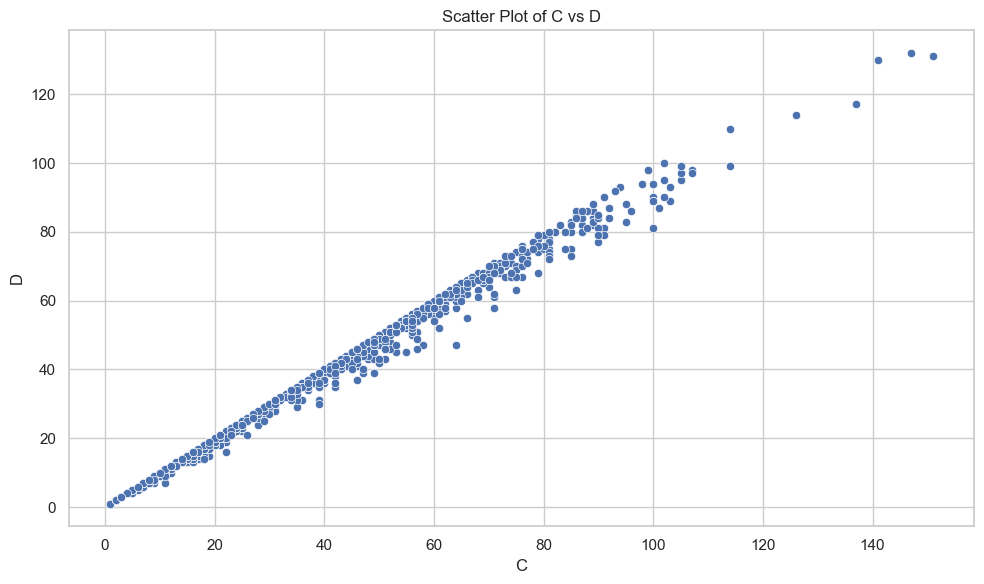

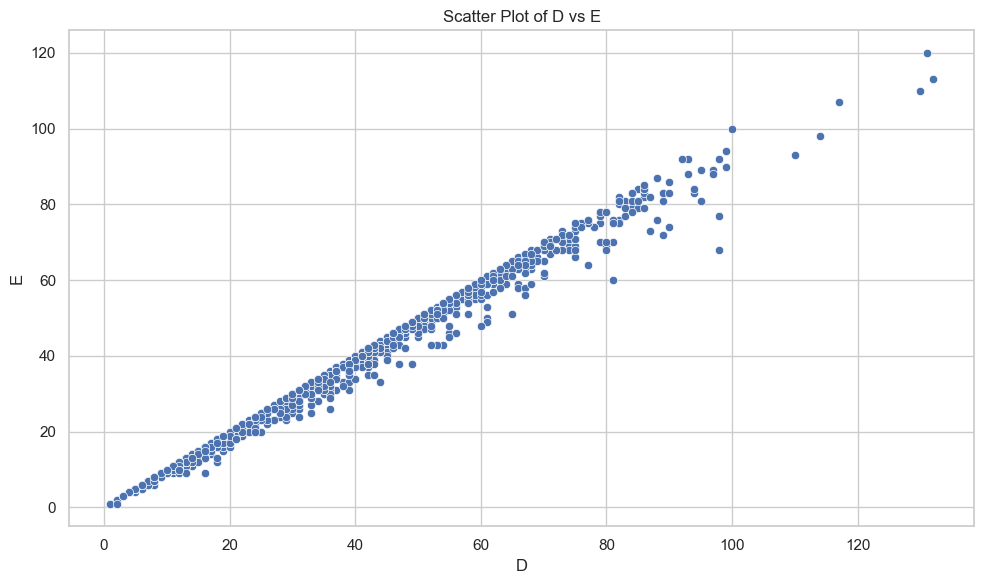

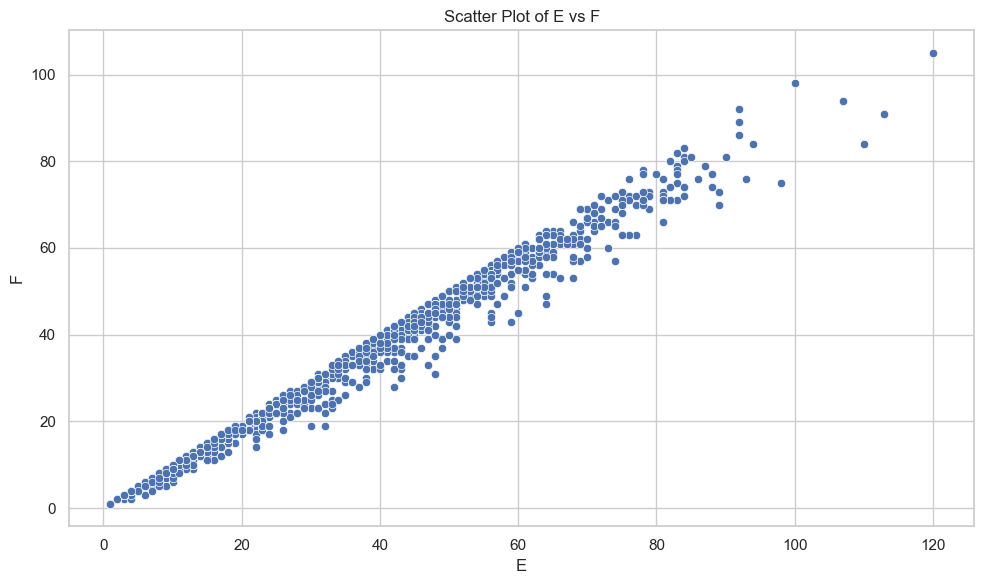

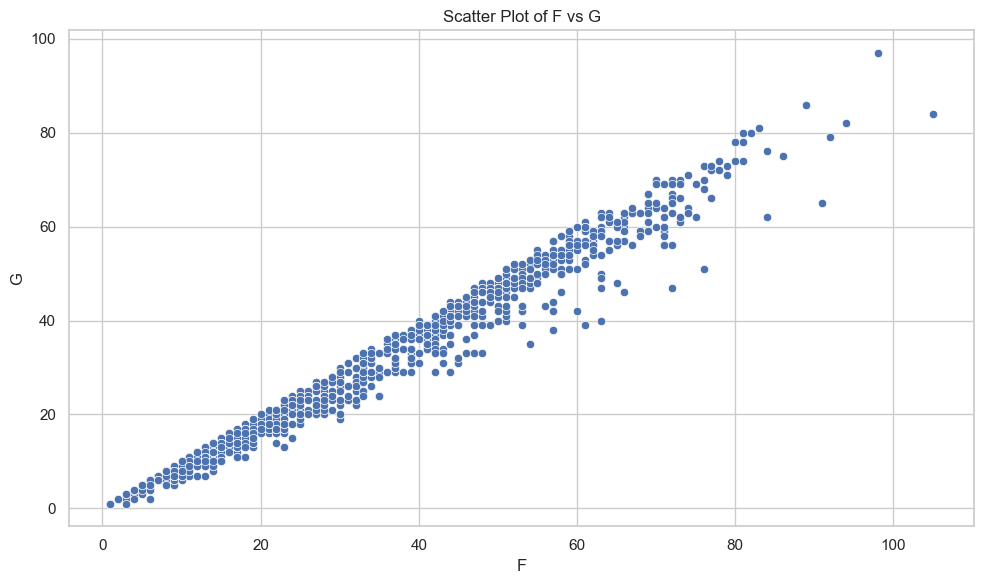

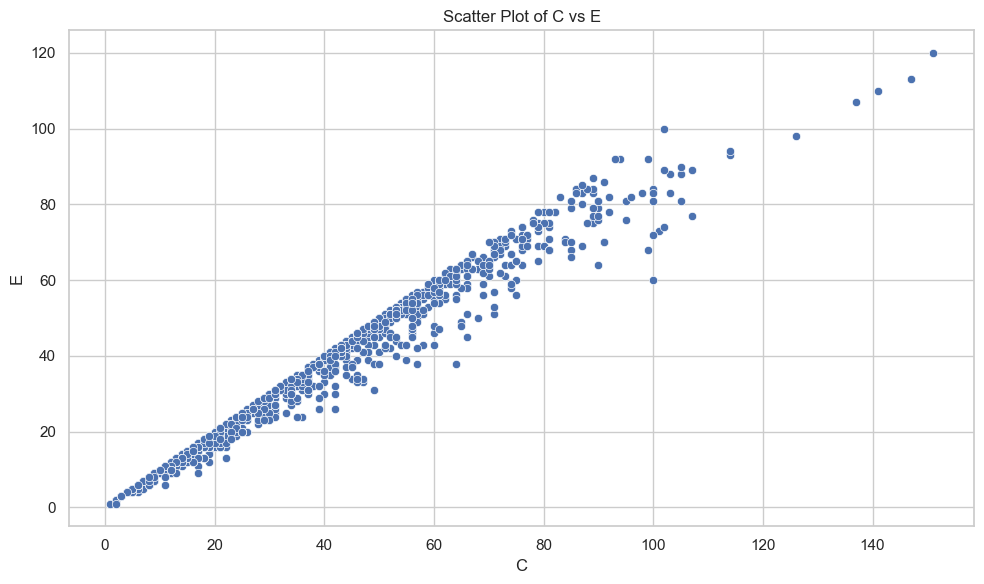

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent figure size for all plots
plt.figure(figsize=(10, 6))

# Scatter plots for highly correlated pairs
correlated_pairs = [('C', 'D'), ('D', 'E'), ('E', 'F'), ('F', 'G'), ('C', 'E')]

for col1, col2 in correlated_pairs:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_clean, x=col1, y=col2)
    plt.title(f'Scatter Plot of {col1} vs {col2}')
    plt.tight_layout()
    plt.show()
    print(f'This scatter plot shows the relationship between {col1} and {col2}.')

This histogram shows the distribution of the highly skewed column A.
This histogram shows the distribution of the highly skewed column B.
This histogram shows the distribution of the highly skewed column I.
This histogram shows the distribution of the highly skewed column J.
This histogram shows the distribution of the highly skewed column K.
This histogram shows the distribution of the highly skewed column L.
This histogram shows the distribution of the highly skewed column M.
This histogram shows the distribution of the highly skewed column N.
This histogram shows the distribution of the highly skewed column O.
This histogram shows the distribution of the highly skewed column P.


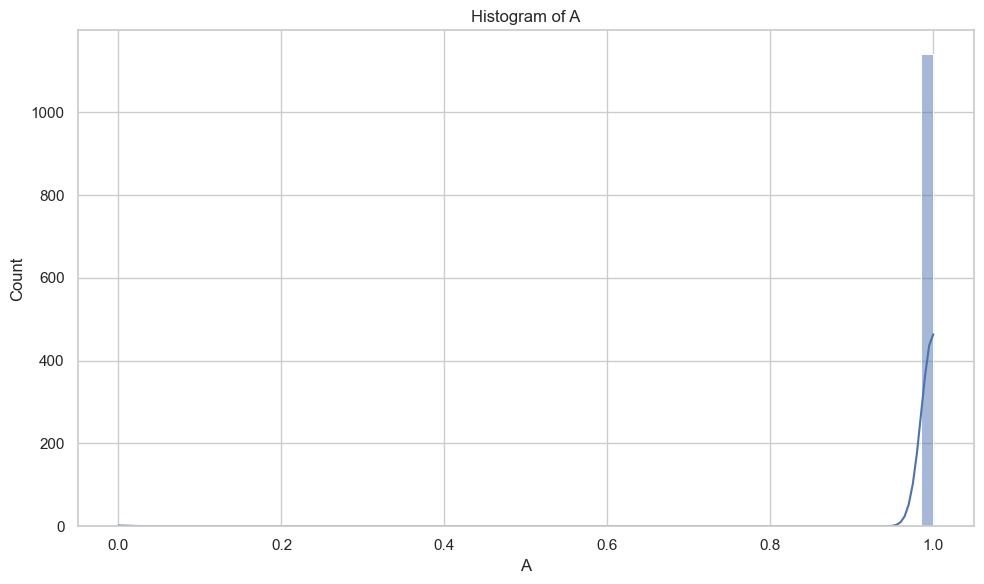

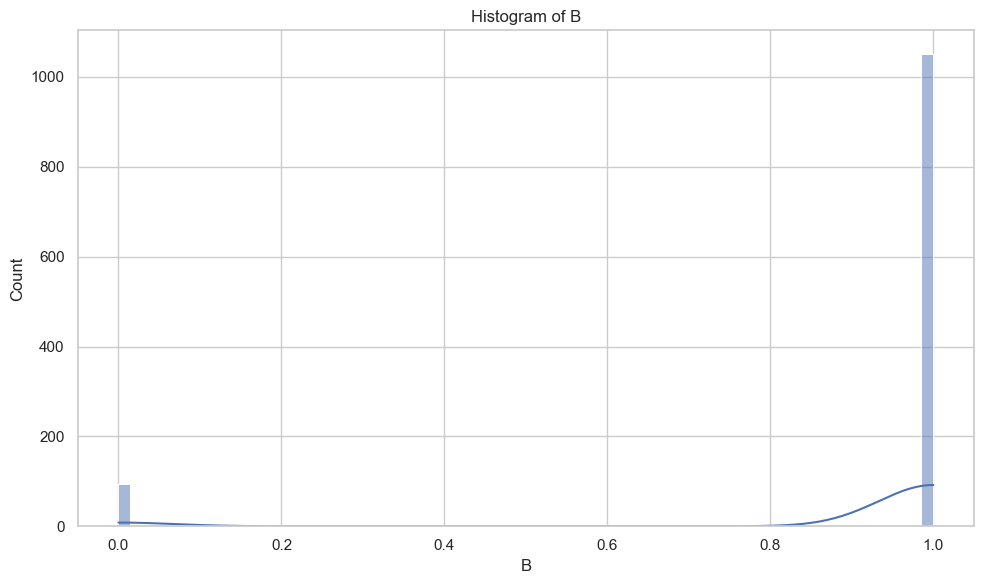

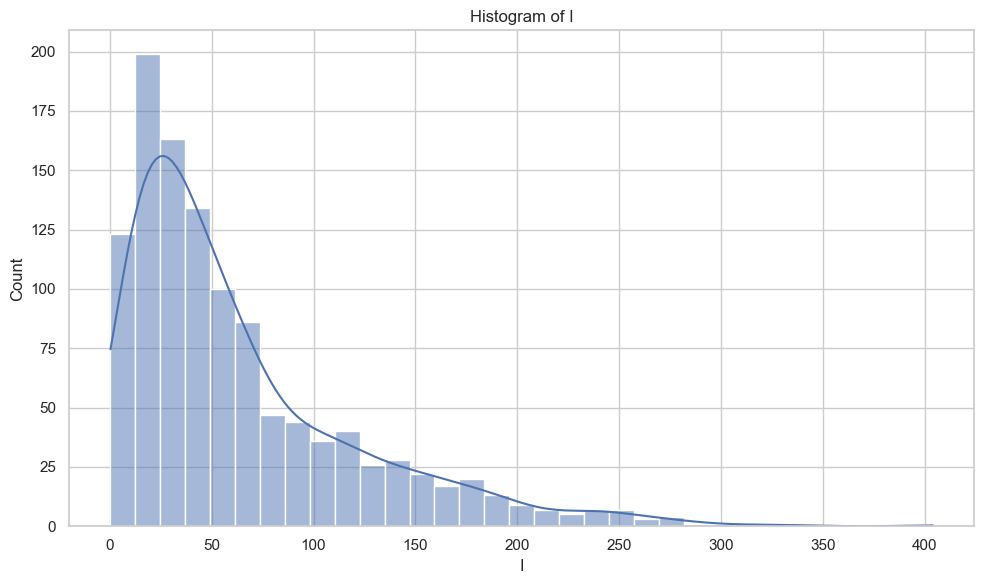

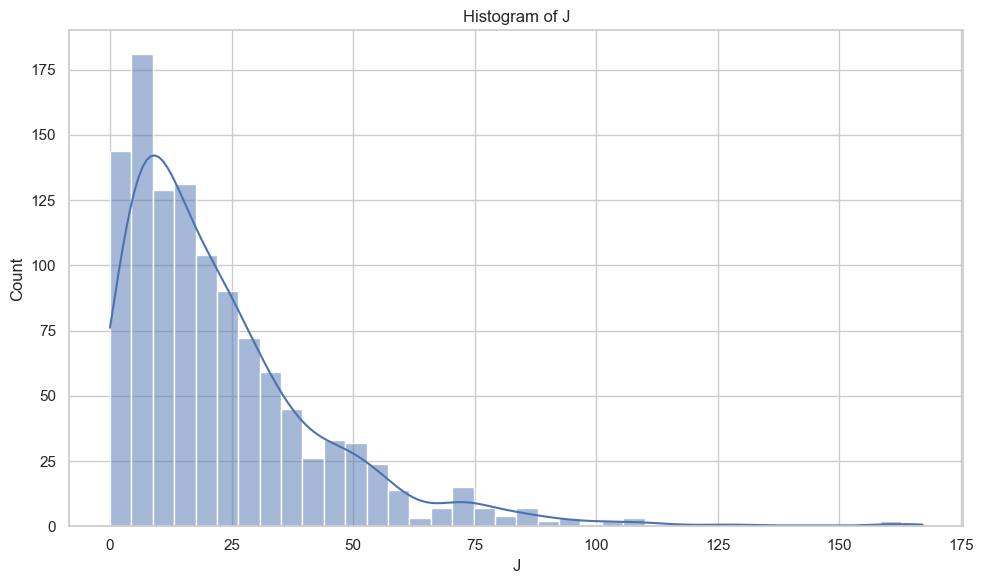

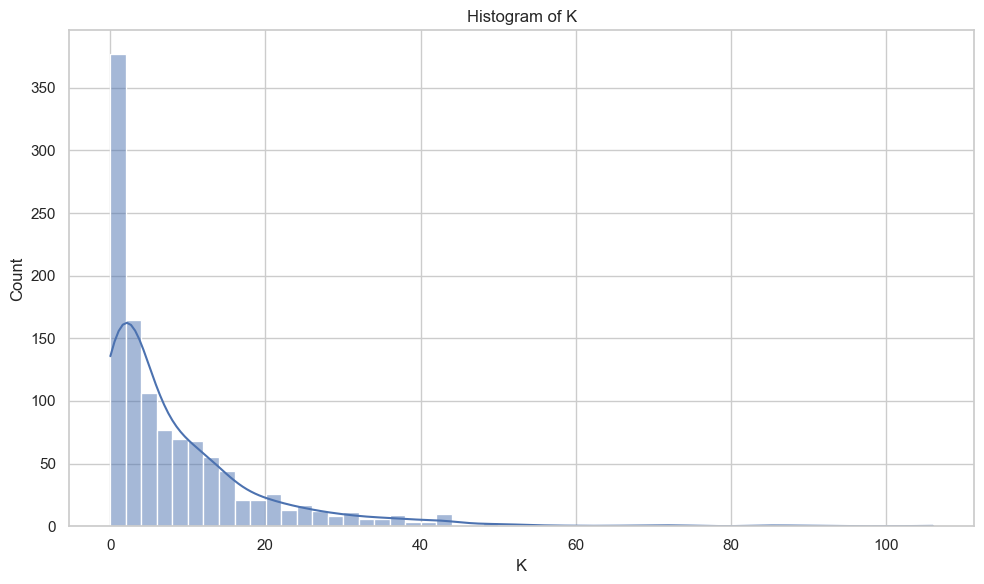

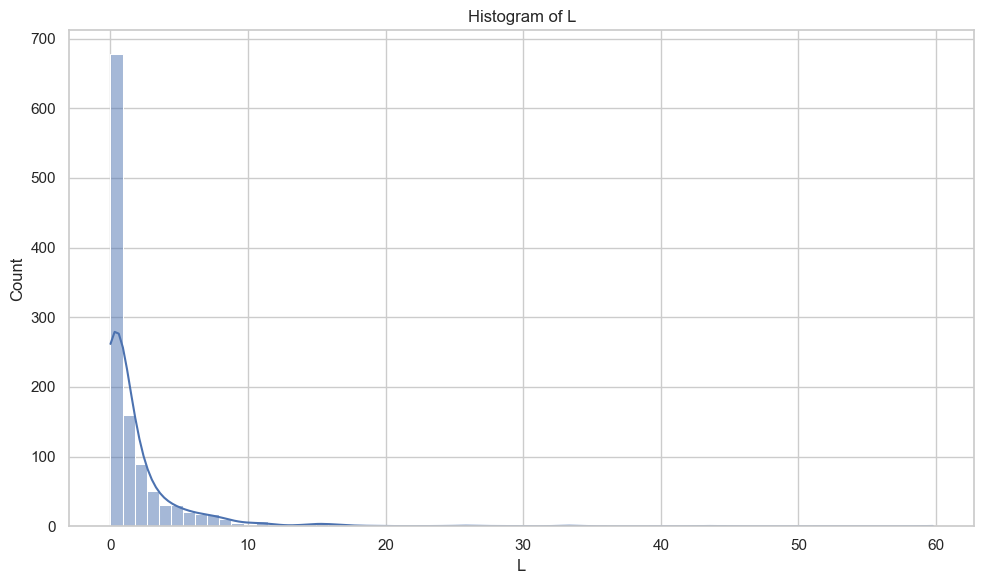

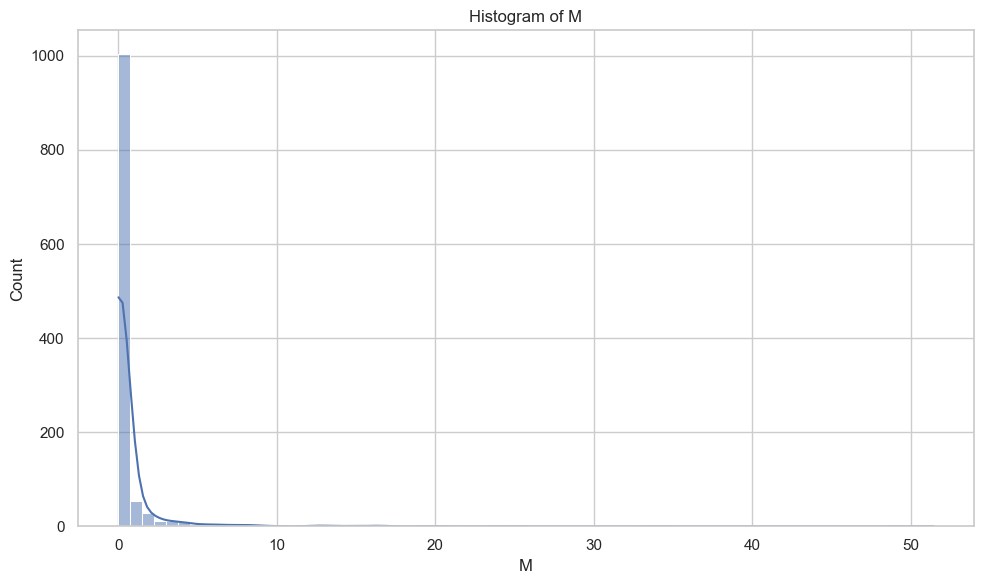

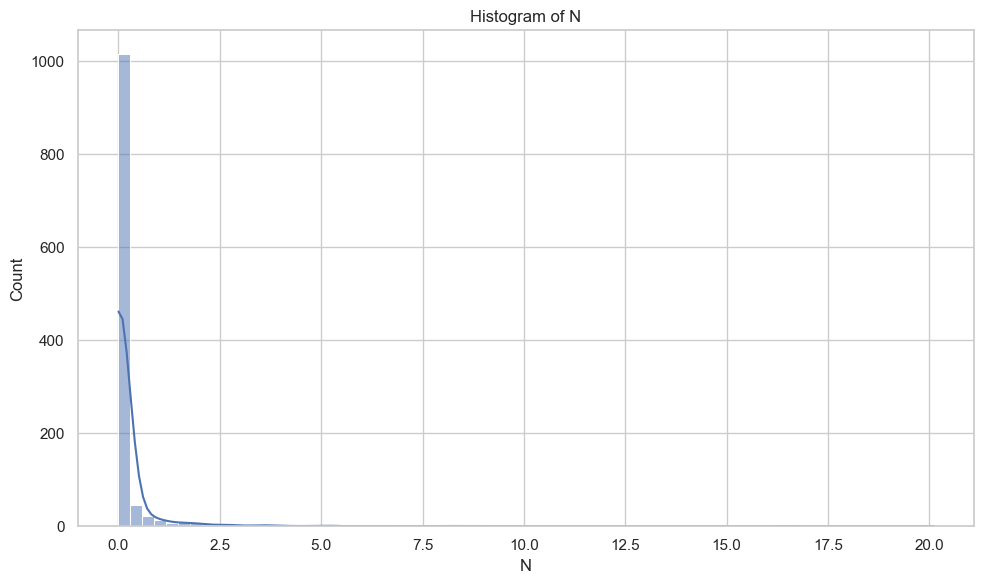

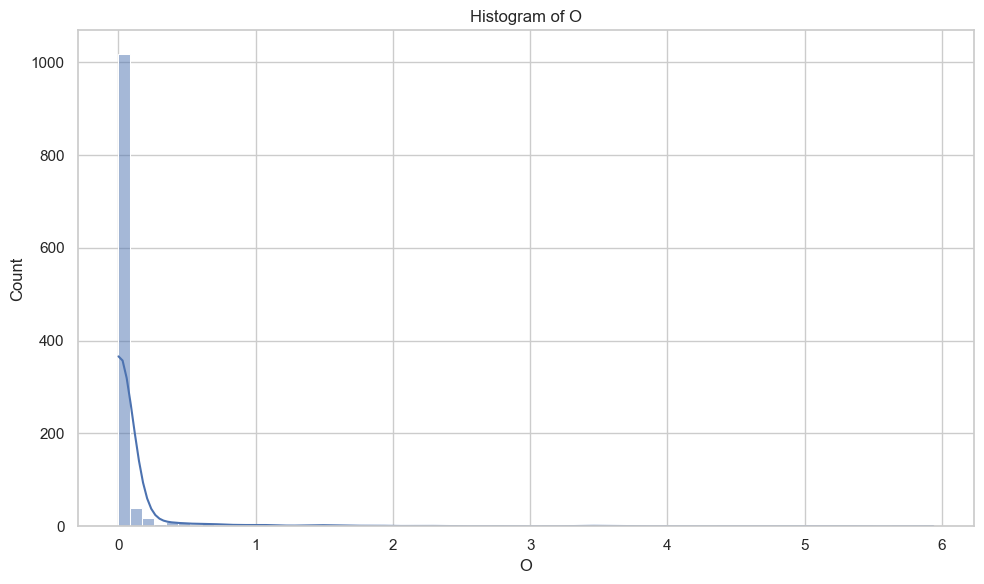

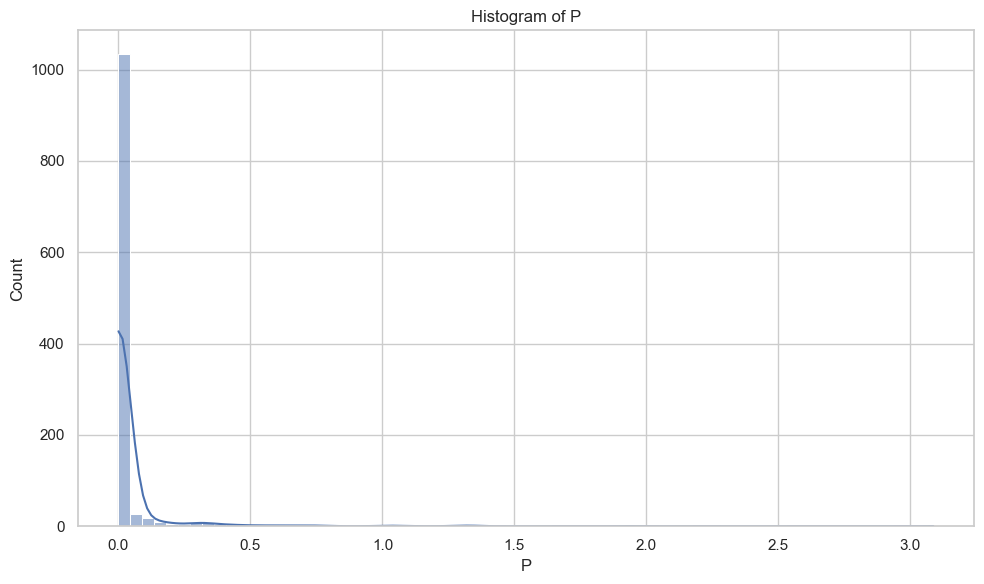

In [ ]:
highly_skewed_columns = ['A', 'B', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']

for col in highly_skewed_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_clean, x=col, kde=True)
    plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.show()
    print(f'This histogram shows the distribution of the highly skewed column {col}.')

This count plot shows the distribution of the binary column A.
This count plot shows the distribution of the binary column B.
This count plot shows the distribution of the binary column S.
This count plot shows the distribution of the binary column T.


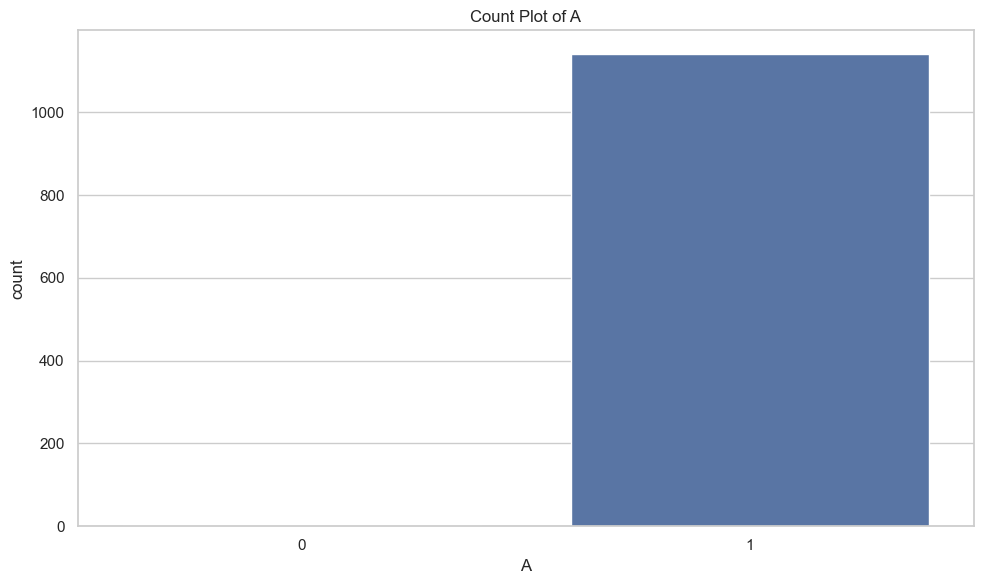

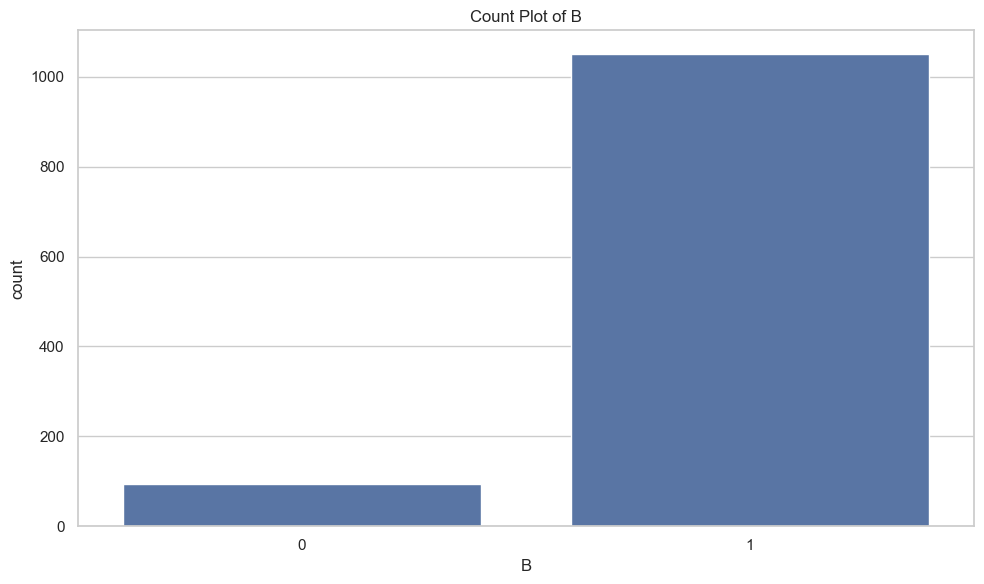

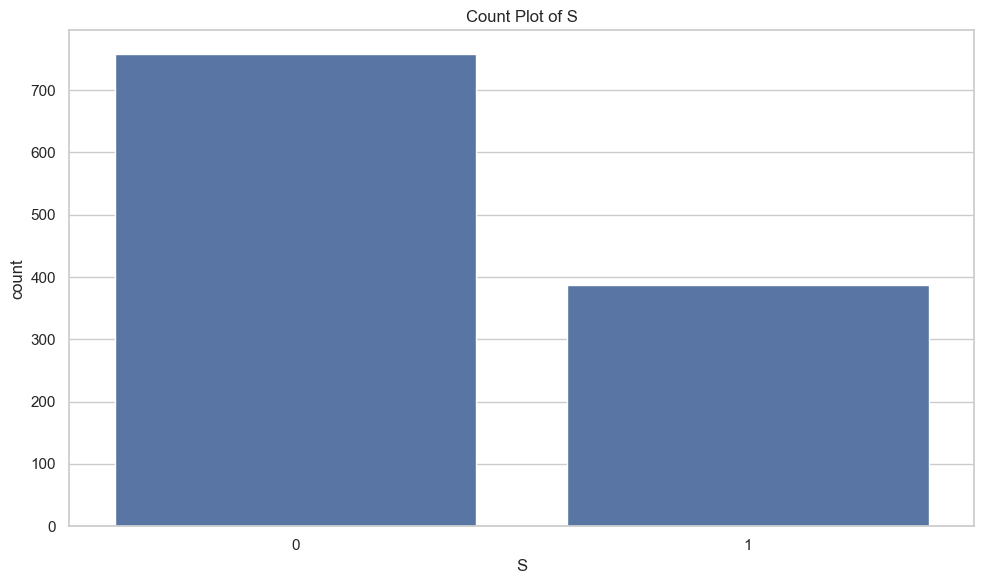

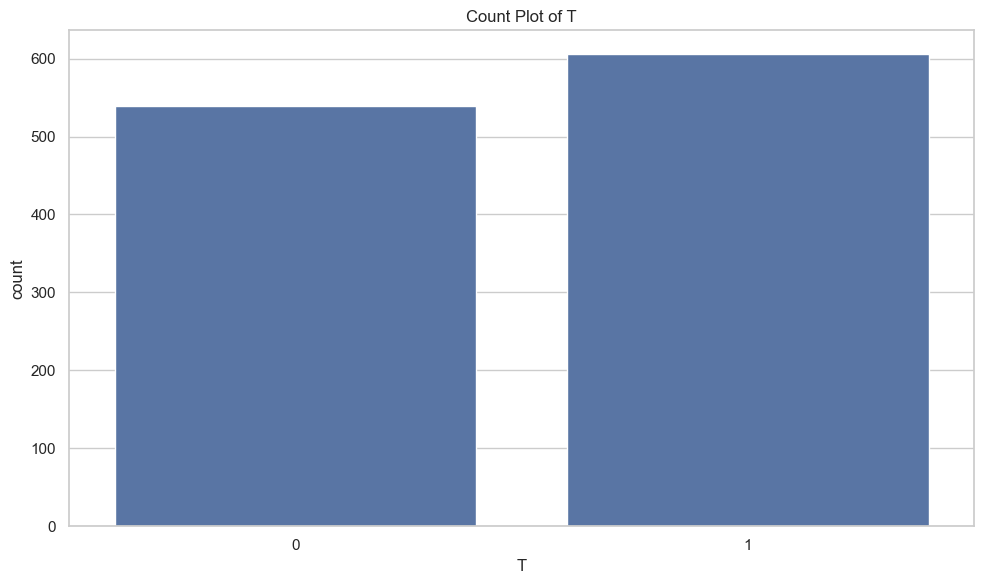

In [ ]:
binary_columns = ['A', 'B', 'S', 'T']

for col in binary_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_clean, x=col)
    plt.title(f'Count Plot of {col}')
    plt.tight_layout()
    plt.show()
    print(f'This count plot shows the distribution of the binary column {col}.')

In [ ]:
print(type(df_raw).__name__)

DataFrame


In [ ]:

_available = {}
for _name in ['df_raw', 'df_clean', 'df_features']:
    _obj = globals().get(_name)
    if _obj is not None and hasattr(_obj, 'shape'):
        _available[_name] = list(_obj.shape)
print(f"Available DataFrames: {_available}")
print(f"NUMERIC_COLUMNS: {globals().get('NUMERIC_COLUMNS', 'NOT SET')}")
print(f"CATEGORICAL_COLUMNS: {globals().get('CATEGORICAL_COLUMNS', 'NOT SET')}")


Available DataFrames: {'df_raw': [1150, 20], 'df_clean': [1145, 20]}
NUMERIC_COLUMNS: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']
CATEGORICAL_COLUMNS: []


In [ ]:
import scipy.stats as stats
import pandas as pd

df = df_clean

print("--- Normality Tests (Shapiro-Wilk) ---")
for col in NUMERIC_COLUMNS:
    if df[col].nunique() > 1: # Shapiro-Wilk requires more than one unique value
        try:
            stat, p = stats.shapiro(df[col])
            print(f'Column {col}: Statistic={stat:.3f}, p={p:.3f}')
            if p < 0.05:
                print(f'  -> Not normal (p < 0.05)')
            else:
                print(f'  -> Appears normal (p >= 0.05)')
        except Exception as e:
            print(f'Column {col}: Error during Shapiro-Wilk test - {e}')
    else:
        print(f'Column {col}: Not enough unique values to perform Shapiro-Wilk test.')

print("\n--- Correlation Significance (Pearson) ---")
correlation_pairs = [('C', 'D'), ('D', 'E'), ('E', 'F'), ('F', 'G'), ('C', 'E')]

for col1, col2 in correlation_pairs:
    if col1 in df.columns and col2 in df.columns:
        corr, p_value = stats.pearsonr(df[col1], df[col2])
        print(f'Correlation between {col1} and {col2}: Pearson r={corr:.3f}, p={p_value:.3f}')
        if p_value < 0.05:
            print(f'  -> Statistically significant (p < 0.05)')
        else:
            print(f'  -> Not statistically significant (p >= 0.05)')
    else:
        print(f'Columns {col1} or {col2} not found in DataFrame.')

--- Normality Tests (Shapiro-Wilk) ---
Column A: Statistic=0.032, p=0.000
  -> Not normal (p < 0.05)
Column B: Statistic=0.305, p=0.000
  -> Not normal (p < 0.05)
Column C: Statistic=0.945, p=0.000
  -> Not normal (p < 0.05)
Column D: Statistic=0.950, p=0.000
  -> Not normal (p < 0.05)
Column E: Statistic=0.951, p=0.000
  -> Not normal (p < 0.05)
Column F: Statistic=0.947, p=0.000
  -> Not normal (p < 0.05)
Column G: Statistic=0.938, p=0.000
  -> Not normal (p < 0.05)
Column H: Statistic=0.929, p=0.000
  -> Not normal (p < 0.05)
Column I: Statistic=0.833, p=0.000
  -> Not normal (p < 0.05)
Column J: Statistic=0.816, p=0.000
  -> Not normal (p < 0.05)
Column K: Statistic=0.703, p=0.000
  -> Not normal (p < 0.05)
Column L: Statistic=0.461, p=0.000
  -> Not normal (p < 0.05)
Column M: Statistic=0.210, p=0.000
  -> Not normal (p < 0.05)
Column N: Statistic=0.189, p=0.000
  -> Not normal (p < 0.05)
Column O: Statistic=0.219, p=0.000
  -> Not normal (p < 0.05)
Column P: Statistic=0.209, p=0.

In [ ]:
print(type(df_raw).__name__)

DataFrame


In [ ]:

_available = {}
for _name in ['df_raw', 'df_clean', 'df_features']:
    _obj = globals().get(_name)
    if _obj is not None and hasattr(_obj, 'shape'):
        _available[_name] = list(_obj.shape)
print(f"Available DataFrames: {_available}")
print(f"NUMERIC_COLUMNS: {globals().get('NUMERIC_COLUMNS', 'NOT SET')}")
print(f"CATEGORICAL_COLUMNS: {globals().get('CATEGORICAL_COLUMNS', 'NOT SET')}")


Available DataFrames: {'df_raw': [1150, 20], 'df_clean': [1145, 20]}
NUMERIC_COLUMNS: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']
CATEGORICAL_COLUMNS: []


In [ ]:
potential_targets = ['A', 'B', 'S', 'T']
found_imbalance = False

for col in potential_targets:
    if col in df_clean.columns:
        unique_vals = df_clean[col].nunique()
        if unique_vals == 2:
            print(f"\nChecking column: {col}")
            counts = df_clean[col].value_counts()
            percentages = df_clean[col].value_counts(normalize=True) * 100
            print("Class Distribution (Counts):")
            print(counts)
            print("Class Distribution (Percentages):")
            print(percentages)
            
            max_percentage = percentages.max()
            min_percentage = percentages.min()
            
            if max_percentage > 70 or min_percentage < 30:
                print(f"Column '{col}' is imbalanced! Majority class is {max_percentage:.2f}% and minority class is {min_percentage:.2f}%.")
                found_imbalance = True
            else:
                print(f"Column '{col}' is balanced. Majority class is {max_percentage:.2f}% and minority class is {min_percentage:.2f}%.")
        elif unique_vals == 0:
            print(f"Column '{col}' is empty.")
        else:
            print(f"\nColumn '{col}' is not a binary column (has {unique_vals} unique values). Skipping imbalance check.")
    else:
        print(f"Column '{col}' not found in DataFrame.")

if not found_imbalance:
    print("\nNo significant class imbalance (i.e., > 70/30 split) detected in the specified binary columns.")



Checking column: A
Class Distribution (Counts):
A
1    1141
0       4
Name: count, dtype: int64
Class Distribution (Percentages):
A
1   99.6507
0    0.3493
Name: proportion, dtype: float64
Column 'A' is imbalanced! Majority class is 99.65% and minority class is 0.35%.

Checking column: B
Class Distribution (Counts):
B
1    1051
0      94
Name: count, dtype: int64
Class Distribution (Percentages):
B
1   91.7904
0    8.2096
Name: proportion, dtype: float64
Column 'B' is imbalanced! Majority class is 91.79% and minority class is 8.21%.

Checking column: S
Class Distribution (Counts):
S
0    758
1    387
Name: count, dtype: int64
Class Distribution (Percentages):
S
0   66.2009
1   33.7991
Name: proportion, dtype: float64
Column 'S' is balanced. Majority class is 66.20% and minority class is 33.80%.

Checking column: T
Class Distribution (Counts):
T
1    606
0    539
Name: count, dtype: int64
Class Distribution (Percentages):
T
1   52.9258
0   47.0742
Name: proportion, dtype: float64
Colum

In [ ]:
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
import numpy as np

# Handle Column 'A' with Class Weights
print("\n--- Handling Class Imbalance for Column 'A' (Class Weights) ---")
if df_clean['A'].nunique() == 2:
    y_A = df_clean['A']
    classes_A = np.unique(y_A)
    weights_A = class_weight.compute_class_weight(class_weight='balanced', classes=classes_A, y=y_A)
    class_weights_dict_A = dict(zip(classes_A, weights_A))
    print("Original Class Distribution (Column 'A'):")
    print(df_clean['A'].value_counts(normalize=True) * 100)
    print("Computed Class Weights for Column 'A':")
    print(class_weights_dict_A)
else:
    print("Column 'A' is not binary, skipping class weight computation.")

# Handle Column 'B' with SMOTE
print("\n--- Handling Class Imbalance for Column 'B' (SMOTE) ---")
if df_clean['B'].nunique() == 2:
    X_B = df_clean.drop(columns=['B'])
    y_B = df_clean['B']
    
    # Before SMOTE
    print("Original Class Distribution (Column 'B'):")
    print(y_B.value_counts(normalize=True) * 100)

    # Check if SMOTE is feasible (at least 6 samples in minority class for default k_neighbors=5)
    minority_class_count_B = y_B.value_counts().min()
    if minority_class_count_B > 5:
        try:
            smote = SMOTE(random_state=42)
            # SMOTE requires X to be numeric, if there are non-numeric columns in X_B, it will fail.
            # For simplicity, I'll drop all non-numeric columns from X_B. 
            # In a real scenario, encoding would be needed for categorical features.
            X_B_numeric = X_B.select_dtypes(include=np.number)
            X_res_B, y_res_B = smote.fit_resample(X_B_numeric, y_B)
            
            print("\nClass Distribution After SMOTE (Column 'B'):")
            print(y_res_B.value_counts(normalize=True) * 100)
        except Exception as e:
            print(f"SMOTE failed for column 'B': {e}")
            print("Consider using class weights or random undersampling instead.")
    else:
        print(f"SMOTE not feasible for column 'B' (minority class has only {minority_class_count_B} samples). Consider using class weights or random undersampling.")
else:
    print("Column 'B' is not binary, skipping SMOTE.")

# Report on 'S' and 'T'
print("\n--- Status of Columns 'S' and 'T' ---")
print("Column 'S' is balanced (66.20% / 33.80%). No imbalance handling needed.")
print("Column 'T' is balanced (52.93% / 47.07%). No imbalance handling needed.")

# Final check to ensure df_features is created/updated if needed
# In this particular case, we are only demonstrating the imbalance handling steps,
# not necessarily modifying df_clean or creating a new df_features here.
# The SMOTE output (X_res_B, y_res_B) is not assigned back to a global df_features
# as the prompt only asked to demonstrate and report, not necessarily save the resampled data.



--- Handling Class Imbalance for Column 'A' (Class Weights) ---
Original Class Distribution (Column 'A'):
A
1   99.6507
0    0.3493
Name: proportion, dtype: float64
Computed Class Weights for Column 'A':
{np.int64(0): np.float64(143.125), np.int64(1): np.float64(0.5017528483786152)}

--- Handling Class Imbalance for Column 'B' (SMOTE) ---
Original Class Distribution (Column 'B'):
B
1   91.7904
0    8.2096
Name: proportion, dtype: float64

Class Distribution After SMOTE (Column 'B'):
B
1   50.0000
0   50.0000
Name: proportion, dtype: float64

--- Status of Columns 'S' and 'T' ---
Column 'S' is balanced (66.20% / 33.80%). No imbalance handling needed.
Column 'T' is balanced (52.93% / 47.07%). No imbalance handling needed.


In [ ]:
print(type(df_raw).__name__)

DataFrame
